In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Dec 2023

@author: Rodrigo Pena
"""
!pip install brian2
from brian2 import *
seed(111)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 21.6 MB/s eta 0:00:00


In [ ]:
I1=open('Inputs_class_orientation1.dat','r')
L1 = open('lbs_class_orientation1.dat','r')
I2=open('Inputs_class_orientation2.dat','r')
L2 = open('lbs_class_orientation2.dat','r')
I3=open('Inputs_class_orientation3.dat','r')
L3 = open('lbs_class_orientation3.dat','r')
I4=open('Inputs_class_orientation4.dat','r')
L4 = open('lbs_class_orientation4.dat','r')


Input1 = I1.read()
Lbl1 = L1.read()
Input2 = I2.read()
Lbl2 = L2.read()
Input3 = I3.read()
Lbl3 = L3.read()
Input4 = I4.read()
Lbl4 = L4.read()

I1.close()
L1.close()
I2.close()
L2.close()
I3.close()
L3.close()
I4.close()
L4.close()


#1 and 2 are inputs, 3 and 4 are labels
destination_file1 = open('Inputs1.dat','w')

destination_file1.write(Input1+Input2)

destination_file1.close()

destination_file2 = open('Inputs2.dat','w')

destination_file2.write(Input3+Input4)

destination_file2.close()

destination_file3 = open('Lbs1.dat','w')

destination_file3.write(Lbl1+Lbl2)

destination_file3.close()

destination_file4 = open('Lbs2.dat','w')

destination_file4.write(Lbl3+Lbl4)

destination_file4.close()


In [ ]:
I1=open('Inputs1.dat','r')
L1 = open('Lbs1.dat','r')
I2=open('Inputs2.dat','r')
L2 = open('Lbs2.dat','r')


Input1 = I1.read()
Lbl1 = L1.read()
Input2 = I2.read()
Lbl2 = L2.read()

I1.close()
I2.close()
L1.close()
L2.close()


#1 and 2 are inputs, 3 and 4 are labels
destination_file1 = open('Inputs_class_Orientation.dat','w')

destination_file1.write(Input1+Input2)

destination_file1.close()

destination_file2 = open('Lbls_Orientation.dat','w')

destination_file2.write(Lbl1+Lbl2)

destination_file2.close()



In [ ]:
"""
Created on Oct 12 2021

@author: rodrigo pena
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pylab
pylab.rcParams['savefig.dpi'] = 120
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef

torch.manual_seed(0)

import seaborn as sn
import pandas as pd
from sklearn.metrics import confusion_matrix
sn.set_style("whitegrid", {'axes.grid' : False})

In [ ]:
pwd

'/content'

In [ ]:
'''load the cross-correlation data from the simulation and the labels'''

data_cxy = np.loadtxt('Inputs_class_Orientation.dat').astype(np.float32)
label_cxy = np.loadtxt('Lbls_Orientation.dat').astype(np.float32)

data_cxy = torch.from_numpy(data_cxy)
label_cxy = torch.from_numpy(label_cxy)

In [ ]:
class Net(nn.Module):
    def __init__(self,D_in,H,D_out):
        super(Net,self).__init__()
        self.linear1 = nn.Linear(D_in,H)
        self.linear2 = nn.Linear(H,D_out)

    def forward(self,x):
        x = torch.tanh(self.linear1(x))
        x = self.linear2(x)
        return x

class Net_relu(nn.Module):
    def __init__(self,D_in,H,D_out):
        super(Net_relu,self).__init__()
        self.linear1 = nn.Linear(D_in,H)
        self.linear2 = nn.Linear(H,D_out)

    def forward(self,x):
        x = torch.relu(self.linear1(x))
        x = self.linear2(x)
        return x

class Net_relu2L(nn.Module):
    def __init__(self,D_in,H,D_out):
        super(Net_relu2L,self).__init__()
        self.linear1 = nn.Linear(D_in,H)
        self.linear2 = nn.Linear(H,H)
        self.linear3 = nn.Linear(H,D_out)

    def forward(self,x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = self.linear3(x)
        return x

class Net_sigmoid(nn.Module):
    def __init__(self,D_in,H,D_out):
        super(Net_sigmoid,self).__init__()
        self.linear1 = nn.Linear(D_in,H)
        self.linear2 = nn.Linear(H,D_out)

    def forward(self,x):
        x = torch.sigmoid(self.linear1(x))
        x = self.linear2(x)
        return x

In [ ]:
input_dim = 9
output_dim = 4
learning_rate=0.0001
# compare lr with real spk trains
H=400
epochs = 2000

model = Net(input_dim,H,output_dim)
optimizer = torch.optim.SGD(model.parameters(),lr = learning_rate, momentum=0.2)
criterion = nn.CrossEntropyLoss()
print(model)

Net(
  (linear1): Linear(in_features=9, out_features=400, bias=True)
  (linear2): Linear(in_features=400, out_features=4, bias=True)
)


In [ ]:
# Print the parameters

print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([400, 9])
b:  torch.Size([400])


In [ ]:
my_data_train = []
my_data_val = []
for i in range(len(data_cxy)):
    if i < len(data_cxy)*0.8:
        my_data_train.append([data_cxy[i], label_cxy[i].type(torch.LongTensor)])
    else:
        my_data_val.append([data_cxy[i], label_cxy[i].type(torch.LongTensor)])

train_set = torch.utils.data.DataLoader(dataset=my_data_train,shuffle=True,batch_size=10)
val_set = torch.utils.data.DataLoader(dataset=my_data_val,shuffle=True,batch_size=10)

In [ ]:
loss_list = []
accuracy_list = []
N_test = len(my_data_val)

def train_model(n_epochs):
    for epoch in range(n_epochs):
        for x,y in train_set:
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z,y)
            loss.backward()
            optimizer.step()

        correct = 0
        for x_test, y_test in val_set:
            z = model(x_test)
            _, yhat = torch.max(z.data,1)
            correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        loss_list.append(loss.data)
        accuracy_list.append(accuracy)
train_model(epochs)

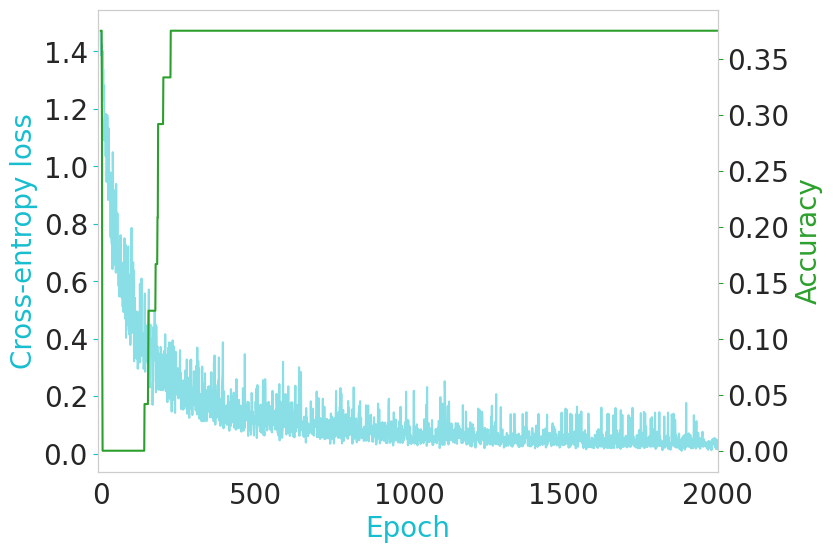

In [ ]:
# Plot the loss and accuracy

fig, ax1 = plt.subplots(figsize=(8, 6))
color = 'tab:cyan'
ax1.plot(loss_list,color=color,alpha=0.5)
ax1.set_xlabel('Epoch',color=color)
ax1.set_ylabel('Cross-entropy loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Accuracy', color=color)
ax2.plot( accuracy_list, color=color,alpha=1)
ax2.tick_params(axis='y', color=color)
# fig.tight_layout()
plt.xlim([-10,epochs])
plt.locator_params(axis='x', nbins=8)
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels() +
            [ax2.title, ax2.xaxis.label, ax2.yaxis.label] +
             ax2.get_xticklabels() + ax2.get_yticklabels()):
    item.set_fontsize(20)

#plt.savefig('Inputs_class_stim1ge4.png')
#plt.savefig('Inputs_class_stim1ge4.eps')

In [ ]:
_, pred_results = torch.max(model(data_cxy),1)
pred_results = pred_results.numpy()

In [ ]:
print(classification_report(label_cxy,pred_results))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       0.67      1.00      0.80        30
         2.0       1.00      1.00      1.00        30
         3.0       1.00      0.50      0.67        30

    accuracy                           0.88       120
   macro avg       0.92      0.88      0.87       120
weighted avg       0.92      0.88      0.87       120



In [ ]:
matthews_corrcoef(label_cxy,pred_results)

0.8512565307587486

In [ ]:
cm=confusion_matrix(label_cxy,pred_results)

In [ ]:
cm

array([[30,  0,  0,  0],
       [ 0, 30,  0,  0],
       [ 0,  0, 30,  0],
       [ 0, 15,  0, 15]])

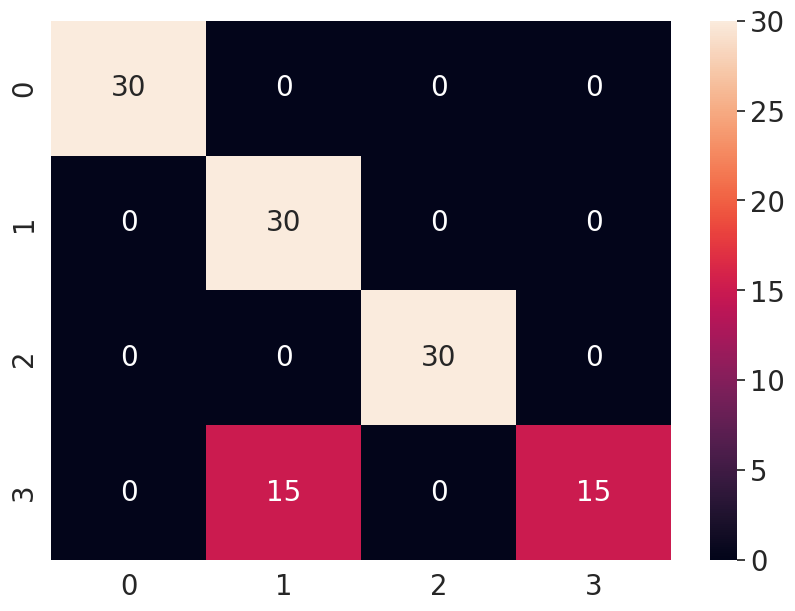

In [ ]:
sn.set(font_scale=1.8)
df_cm = pd.DataFrame(cm, index = [i for i in ["0", "1","2","3"]], columns = [i for i in ["0", "1","2","3"]])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, annot_kws={"size": 20}) #

plt.savefig('cmInputs_class_stim1ge4.png')
plt.savefig('cmInputs_class_stim1ge4.eps')

In [ ]:
#@title Mount drive
#mount drive
#from google.colab import drive
#drive.mount('/content/gdrive')
#images_dir = '/content/gdrive/MyDrive/Systematic_Diagrams'

In [2]:
def fixed_indegree(indegree,n_post_pop,n_pre_pop):
    np.random.seed(10)
    presyn_indices = np.zeros([n_post_pop*indegree])
    postsyn_indices = np.zeros([n_post_pop*indegree])
    counter = 0

    for post in range(n_post_pop):
        x = np.arange(0, n_pre_pop)
        y = np.random.permutation(x)
        for i in range(indegree):
            presyn_indices[counter] = y[i]
            postsyn_indices[counter] = post
            counter += 1
    presyn_indices = presyn_indices.astype(int)
    postsyn_indices = postsyn_indices.astype(int)
    return presyn_indices, postsyn_indices


In [3]:
def simulation(tf,orien,pope_pref = 10, popi_pref = 90, pl=0,size_orientation=30):
    #seed(10)
    #net parameters
    NE = 4000
    gamma = 0.2
    NI = int(gamma*NE)
    CE = int(NE*0.2)
    CI = int(gamma*CE)
    tau = 20*ms
    tref = 2*ms
    vth = 20
    vr = 0
    J = 0.1
    g = 8
    D = 3*ms

    eqs='''
        dv/dt = (-v + I)/tau : 1 (unless refractory)
        I = current_amplitude * cos((pi/180)*(stimulus_orientation - preferred_orientation)) * exp(-0.5 * ((stimulus_orientation - preferred_orientation) / orientation_tuning_width)**2) : 1
        preferred_orientation : 1
        current_amplitude : 1 (shared)
        stimulus_orientation : 1 (shared)
        orientation_tuning_width : 1 (shared)
        '''

        # orientation_tuning_width : 1 (shared)

    #neurons

    neurons = NeuronGroup(NE+NI,eqs,method='euler',dt=0.01*ms,threshold='v>=vth',reset='v=vr',refractory=tref)
    neurons.v = 'rand()*(vth-vr) + vr'
    pop_e = neurons[:NE] #[:NE]
    pop_i = neurons[NE:(NE+NI)]

    # # Set up orientation-selective current

    neurons[:NE].preferred_orientation = pope_pref  # Preferred orientation in degrees
    #neurons[2000:NE].preferred_orientation = pope_pref2
    #---
    neurons[NE:(NE+NI)].preferred_orientation = popi_pref  # Preferred orientation in degrees
    neurons.stimulus_orientation = orien  # Stimulus orientation in degrees
    # Generate cosine-tuned current profile
    neurons.current_amplitude = 50
    neurons.orientation_tuning_width = size_orientation

    #Poisson
    P = PoissonInput(neurons, 'v', NE+NI, 1*Hz, weight=2*J)

    #E indexes
    presyn_indices,postsyn_indices=fixed_indegree(CE,(NE+NI),NE)
    con_e = Synapses(pop_e, neurons, on_pre='v += J', delay=D,dt=0.01*ms)
    con_e.connect(i=presyn_indices,j=postsyn_indices)

    #I indexes
    presyn_indices,postsyn_indices=fixed_indegree(CI,(NE+NI),NI)
    con_i = Synapses(pop_i, neurons, on_pre='v -= J*g', delay=D,dt=0.01*ms)
    con_i.connect(i=presyn_indices,j=postsyn_indices)


    ratemon = PopulationRateMonitor(neurons)
    spkmon = SpikeMonitor(neurons)

    net = Network(neurons, pop_e, pop_i, con_e, con_i, P, spkmon, ratemon)
    net.run(tf,'stdout')

    if(pl==1):

        subplot(2,1,1)
        plot(spkmon.t/ms,spkmon.i,'k.',markersize=0.5)
        # ylim(950,1000)
        xlim(1000,1800)

        subplot(2,1,2)
        plot(ratemon.t/ms, ratemon.rate/Hz)
        xlim(1000,1800)
        show()

    return spkmon, ratemon

### Single Run with Individual Rates

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 8s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 8s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s


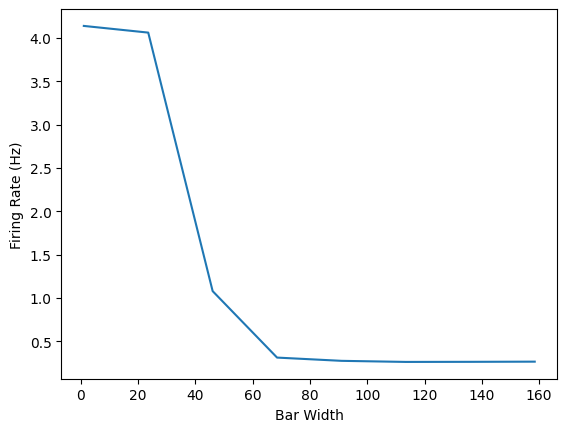

In [12]:
import numpy as np
import matplotlib.pyplot as plt

trials = 1
rr = np.arange(1,180,22.5)
individual_rates = np.zeros((len(rr),4799))
count=0

###for orien 0:180

for k in range(trials):
    mfr = []
    tf=200*ms
    for i in rr:
        spks,rate = simulation(tf=tf,orien=150,pope_pref=30,popi_pref=60,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
        a = spks.t/ms
        b = spks.i
        for k in range(np.max(b)):
          aux = a[where(b==k)[0]]
          individual_rates[count,k] = len(aux)/1.0
        count = count + 1
    plt.plot(rr,mfr,'-')
    plt.xlabel("Bar Width")
    plt.ylabel("Firing Rate (Hz)")
    #savefig(f"{images_dir}/" + str() + "_180_180.pdf")

In [13]:
mfr

[4.13958333 * hertz,
 4.0625 * hertz,
 1.08020833 * hertz,
 313.54166667 * mhertz,
 276.04166667 * mhertz,
 263.54166667 * mhertz,
 264.58333333 * mhertz,
 266.66666667 * mhertz]

In [ ]:
test = mfr / Hz

In [ ]:
mfr1 = []
for i in range(len(mfr)):
  temp = mfr[i] / Hz
  mfr1.append(temp)

In [ ]:
type(mfr1)

list

### Only mfr

In [ ]:
trials = 15
# changed from 8 to 2 for 4 separate files
Inputs_class = np.zeros((2*trials,9))
lbs = np.zeros((2*trials,1))

for m in range(trials):

    #Peak pattern
    trial = 1
    rr = np.arange(1,180,20)

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=110,pope_pref=90,popi_pref=30,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[m,:] = mfr1
      lbs[m,:] = 0
    # different graphical pattern, still representing peak
    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=30,pope_pref=180,popi_pref=150,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[trials+m,:] = mfr1
      lbs[trials+m,:] = 0

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 9s
Starting simulation at t=0. s for a duration of 200. ms
69.64 ms (34%) simulated in 10s, estimated 19s remaining.
177.39 ms (88%) simulated in 20s, estimated 3s remaining.
200. ms (100%) simulated in 22s
Starting simulation at t=0. s for a duration of 200. ms
156.16 ms (78%) simulated in 10s, estimated 3s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 9s
Starting simulation at t=0. s for a duration of 200. ms
133.33 ms (66%) simulated in 10s, estimated 5s remaining.
200. ms (100%) simulated in 14s
Starting simulation at t=0. s for a duration of 200. ms
169.2 ms (84%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 11s
Starting simulation at t=0. s for a duration of 200. ms
154.21 ms (77%) simulated in 10s, estimate

In [ ]:
np.savetxt('Inputs_class_orientation1.dat',Inputs_class)
np.savetxt('lbs_class_orientation1.dat',lbs)

In [ ]:
trials = 15

Inputs_class = np.zeros((2*trials,9))
lbs = np.zeros((2*trials,1))

for m in range(trials):

    #Valley pattern
    trial = 1
    rr = np.arange(1,180,20)

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=30,pope_pref=120,popi_pref=60,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
        #only did trials instead of times 2 cause 4 separate files
      #Inputs_class[2*trials+m,:] = mfr1
      Inputs_class[m,:] = mfr1
      lbs[m,:] = 1
    # different graphical pattern, still representing valley
    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=90,pope_pref=180,popi_pref=150,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[trials+m,:] = mfr1
      lbs[trials+m,:] = 1

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duratio

In [ ]:
np.savetxt('Inputs_class_orientation2.dat',Inputs_class)
np.savetxt('lbs_class_orientation2.dat',lbs)

In [ ]:
trials = 15

Inputs_class = np.zeros((2*trials,9))
lbs = np.zeros((2*trials,1))

for m in range(trials):

    #Increasing pattern
    trial = 1
    rr = np.arange(1,180,20)

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=0,pope_pref=30,popi_pref=60,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[m,:] = mfr1
      lbs[m,:] = 2
    # different graphical pattern, still representing increasing
    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=150,pope_pref=90,popi_pref=60,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[trials+m,:] = mfr1
      lbs[trials+m,:] = 2

Starting simulation at t=0. s for a duration of 200. ms
116.77 ms (58%) simulated in 10s, estimated 7s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
131.39 ms (65%) simulated in 10s, estimated 5s remaining.
200. ms (100%) simulated in 19s
Starting simulation at t=0. s for a duration of 200. ms
120.89 ms (60%) simulated in 10s, estimated 7s remaining.
200. ms (100%) simulated in 15s
Starting simulation at t=0. s for a duration of 200. ms
127.42 ms (63%) simulated in 10s, estimated 6s remaining.
200. ms (100%) simulated in 15s
Starting simulation at t=0. s for a duration of 200. ms
136.77 ms (68%) simulated in 10s, estimated 5s remaining.
200. ms (100%) simulated in 14s
Starting simulation at t=0. s for a duration of 200. ms
116.47 ms (58%) simulated in 10s, estimated 7s remaining.
200. ms (100%) simulated in 16s
Starting simulation at t=0. s for a d

In [ ]:
np.savetxt('Inputs_class_orientation3.dat',Inputs_class)
np.savetxt('lbs_class_orientation3.dat',lbs)

In [ ]:
trials = 15

Inputs_class = np.zeros((2*trials,9))
lbs = np.zeros((2*trials,1))

for m in range(trials):

    #Decreasing pattern
    trial = 1
    rr = np.arange(1,180,20)

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=150,pope_pref=0,popi_pref=60,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[m,:] = mfr1
      lbs[m,:] = 3
    # different graphical pattern, still representing decreasing
    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
        spks,rate = simulation(tf=tf,orien=30,pope_pref=150,popi_pref=30,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
      mfr1 = []
      for i in range(len(mfr)):
        temp = mfr[i] / Hz
        mfr1.append(temp)
      Inputs_class[trials+m,:] = mfr1
      lbs[trials+m,:] = 3

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 6s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duratio

In [ ]:
np.savetxt('Inputs_class_orientation4.dat',Inputs_class)
np.savetxt('lbs_class_orientation4.dat',lbs)

In [ ]:
trials = 5

Inputs_class = np.zeros((4*trials,9))
lbs = np.zeros((4*trials,1))

for m in range(trials):

    #Peak pattern
    trial = 1
    rr = np.arange(1,180,20)
    individual_rates = np.zeros((len(rr),4799))
    count=0

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
          spks,rate = simulation(tf=tf,orien=110,pope_pref=90,popi_pref=30,pl=0,size_orientation=i)
          mfr.append(mean(spks.count)/tf)
          a = spks.t/ms
          b = spks.i
          for k in range(np.max(b)):
            aux = a[where(b==k)[0]]
            individual_rates[count,k] = len(aux)/1.0
          count = count + 1
      Inputs_class[m,:] = mfr[1,:] / Hz
      lbs[m,:] = 0

    #Valley pattern
    trial = 1
    rr = np.arange(1,180,20)
    individual_rates = np.zeros((len(rr),4799))
    count=0

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
          spks,rate = simulation(tf=tf,orien=30,pope_pref=120,popi_pref=60,pl=0,size_orientation=i)
          mfr.append(mean(spks.count)/tf)
          a = spks.t/ms
          b = spks.i
          for k in range(np.max(b)):
            aux = a[where(b==k)[0]]
            individual_rates[count,k] = len(aux)/1.0
          count = count + 1
      Inputs_class[m,:] = mfr[1,:] / Hz
      lbs[m,:] = 1

    #increasing pattern
    trial = 1
    rr = np.arange(1,180,20)
    individual_rates = np.zeros((len(rr),4799))
    count=0

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
          spks,rate = simulation(tf=tf,orien=0,pope_pref=30,popi_pref=60,pl=0,size_orientation=i)
          mfr.append(mean(spks.count)/tf)
          a = spks.t/ms
          b = spks.i
          for k in range(np.max(b)):
            aux = a[where(b==k)[0]]
            individual_rates[count,k] = len(aux)/1.0
          count = count + 1
      Inputs_class[m,:] = mfr[1,:] / Hz
      lbs[m,:] = 2

    #Decreasing pattern
    trial = 1
    rr = np.arange(1,180,20)
    individual_rates = np.zeros((len(rr),4799))
    count=0

    for k in range(trial):
      mfr = []
      tf=200*ms
      for i in rr:
          spks,rate = simulation(tf=tf,orien=150,pope_pref=0,popi_pref=60,pl=0,size_orientation=i)
          mfr.append(mean(spks.count)/tf)
          a = spks.t/ms
          b = spks.i
          for k in range(np.max(b)):
            aux = a[where(b==k)[0]]
            individual_rates[count,k] = len(aux)/1.0
          count = count + 1
      Inputs_class[m,:] = mfr[1,:] / Hz
      lbs[m,:] = 3

#np.savetxt('Inputs_class_orientation.dat',Inputs_class)
#np.savetxt('lbs_class_orientation.dat',lbs)

KeyboardInterrupt: 

In [ ]:
individual_rates

array([[2., 0., 1., ..., 3., 1., 2.],
       [2., 0., 1., ..., 3., 1., 2.],
       [1., 0., 1., ..., 2., 0., 1.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
savefig(f"{images_dir}/65_100_130.pdf")

<Figure size 640x480 with 0 Axes>

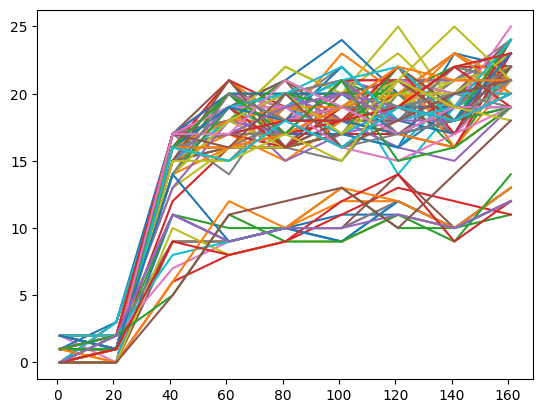

In [ ]:
singNeuron = np.zeros(len(individual_rates))
range1 = np.arange(0,4799,50)
for j in range1:
  for i in range(len(individual_rates)):
    singNeuron[i] = (individual_rates[i][j])
  plt.plot(np.arange(1,180,20),singNeuron,'-')

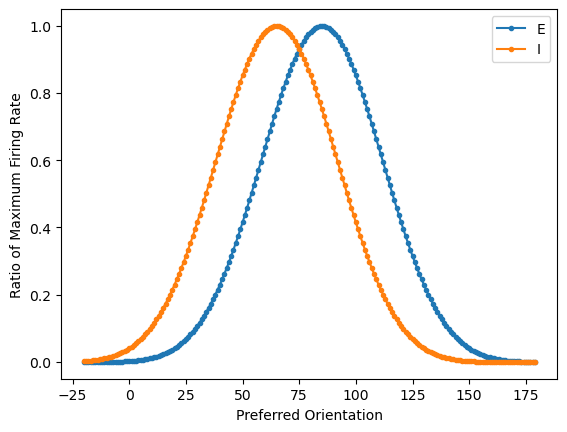

In [4]:
#  I = current_amplitude * cos((pi/180)*(stimulus_orientation - preferred_orientation)) * exp(-0.5 * ((stimulus_orientation - preferred_orientation) / orientation_tuning_width)**2) : 1

rr = np.arange(-20,180,1)

pope=85
popi=65
acum=[];
for i in rr:
    acum.append(np.cos((np.pi/180)*(i - pope)) * np.exp(-0.5 * ((i - pope) / 30)**2))

acumi=[];
for i in rr:
    acumi.append(np.cos((np.pi/180)*(i - popi)) * np.exp(-0.5 * ((i - popi) / 30)**2))

plt.plot(rr, acum, '.-', label='E')
plt.plot(rr, acumi, '.-', label='I')

plt.xlabel('Preferred Orientation')
plt.ylabel('Ratio of Maximum Firing Rate')

plt.legend()
plt.show()

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 5s
Starting simulation at t=0. s for a duration of 200. ms
110.97 ms (55%) simulated in 10s, estimated 8s remaining.
200. ms (100%) simulated in 16s
Starting simulation at t=0. s for a duration of 200. ms
153.33 ms (76%) simulated in 10s, estimated 3s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
165.57 ms (82%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 7s
Starting simulation at t=0. s for a duration of 200. ms
135.58 ms (67%) simulated in 10s, estimated 5s remaining.
200. ms (100%) simulated in 16s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 8s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 8s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100

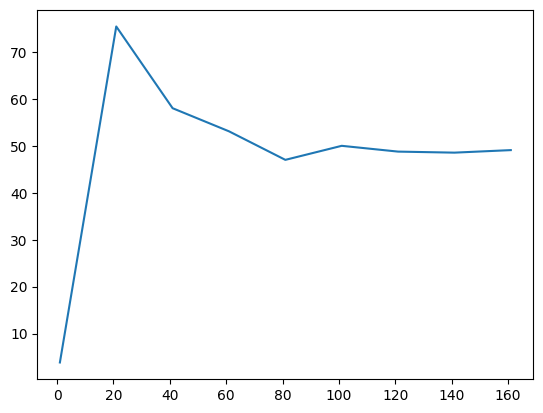

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

trials = 1
rr = np.arange(1,180,20)

for k in range(trials):
    mfr = []
    tf=200*ms
    for i in rr:
        spks,rate = simulation(tf=tf,orien=85, pope_pref = 55, popi_pref = 120,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
    # plt.subplot(2,2,k+1)
    plt.plot(rr,mfr,'-')

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 2s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 3s


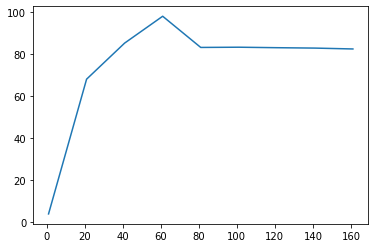

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

trials = 1
rr = np.arange(1,180,20)

for k in range(trials):
    mfr = []
    tf=200*ms
    for i in rr:
        spks,rate = simulation(tf=tf,orien=110, pope_pref = 150, popi_pref = 30,pl=0,size_orientation=i)
        mfr.append(mean(spks.count)/tf)
    # plt.subplot(2,2,k+1)
    plt.plot(rr,mfr,'-')